In [1]:
import geopandas as gpd
import pandas as pd
pd.set_option('display.max_columns', None)

In [2]:
sa2 = gpd.read_file("input/statsnz-2023-census-population-change-by-statistical-area-2-FGDB.zip!2023-census-population-change-by-statistical-area-2.gdb").sort_values("VAR_1_3")
sa2 = sa2[sa2.LAND_AREA_SQ_KM > 0]
sa2["n_SA2s"] = 1
sa2

/home/nyou045/.local/lib/python3.12/site-packages/pyogrio/raw.py:198: RuntimeWarning: organizePolygons() received a polygon with more than 100 parts.  The processing may be really slow.  You can skip the processing by setting METHOD=SKIP.
  return ogr_read(


,SA22023_V1_00,SA22023_V1_00_NAME,SA22023_V1_00_NAME_ASCII,VAR_1_1,VAR_1_2,VAR_1_3,VAR_1_4,VAR_1_5,AREA_SQ_KM,LAND_AREA_SQ_KM,Shape_Length,geometry,n_SA2s
120,190000,Te More,Te More,0,0,0,-998.0,-998.0,47.922581,47.922581,33420.011116,"MULTIPOLYGON (((1862216.162 5670176.109, 18622...",1
2387,259800,Bare Island,Bare Island,0,0,0,-998.0,-998.0,0.131629,0.131629,2288.455490,"MULTIPOLYGON (((1944778.981 5583219.772, 19448...",1
1100,246500,Towai,Towai,0,0,0,-998.0,-998.0,5.007264,5.007264,16148.525742,"MULTIPOLYGON (((1763185.172 5435869.142, 17633...",1
264,258100,Three Kings Islands,Three Kings Islands,0,0,0,-998.0,-998.0,4.966434,4.966434,34486.441022,"MULTIPOLYGON (((1521300.863 6221544.192, 15213...",1
867,364000,Motunau Island,Motunau Island,0,0,0,-998.0,-998.0,0.081474,0.081474,1427.156234,"MULTIPOLYGON (((1606252.965 5232456.967, 16062...",1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
953,109301,Dargaville,Dargaville,4284,4827,5016,12.7,3.9,12.857900,12.857900,22435.405699,"MULTIPOLYGON (((1678269.425 6024387.291, 16782...",1
160,117001,Whenuapai,Whenuapai,3150,3270,5052,3.8,54.5,12.753226,12.753226,26571.209745,"MULTIPOLYGON (((1743880.554 5928979.708, 17438...",1
252,335501,Faringdon,Faringdon,153,2745,5553,1694.1,102.3,3.566076,3.566076,9064.072284,"MULTIPOLYGON (((1549864.157 5168679.437, 15498...",1
1860,120202,Hobsonville Point Park,Hobsonville Point Park,642,2106,5562,228.0,164.1,1.033846,1.033846,6576.909403,"MULTIPOLYGON (((1748048.931 5927315.847, 17480...",1


In [3]:
dz = sa2.head(1)
dz

,SA22023_V1_00,SA22023_V1_00_NAME,SA22023_V1_00_NAME_ASCII,VAR_1_1,VAR_1_2,VAR_1_3,VAR_1_4,VAR_1_5,AREA_SQ_KM,LAND_AREA_SQ_KM,Shape_Length,geometry,n_SA2s
120,190000,Te More,Te More,0,0,0,-998.0,-998.0,47.922581,47.922581,33420.011116,"MULTIPOLYGON (((1862216.162 5670176.109, 18622...",1


In [4]:
neighbours = sa2[sa2.geometry.touches(dz.geometry.iloc[0])]
neighbours

,SA22023_V1_00,SA22023_V1_00_NAME,SA22023_V1_00_NAME_ASCII,VAR_1_1,VAR_1_2,VAR_1_3,VAR_1_4,VAR_1_5,AREA_SQ_KM,LAND_AREA_SQ_KM,Shape_Length,geometry,n_SA2s
624,226200,Ngamatea,Ngamatea,27,24,24,-11.1,0.0,611.566800,611.566800,202250.247641,"MULTIPOLYGON (((1872206.933 5663447.622, 18722...",1
597,189900,Taharua,Taharua,57,57,81,0.0,42.1,784.238848,784.238848,222344.510569,"MULTIPOLYGON (((1882617.863 5690382.777, 18842...",1
218,189500,Kaimanawa,Kaimanawa,6,180,312,2900.0,73.3,1342.255643,1342.255643,274855.842659,"MULTIPOLYGON (((1885276.54 5703414.98, 1882658...",1
442,226100,Mokai Patea,Mokai Patea,1761,1716,1749,-2.6,1.9,2474.888801,2474.888801,452648.105043,"MULTIPOLYGON (((1857172.488 5662356.168, 18630...",1


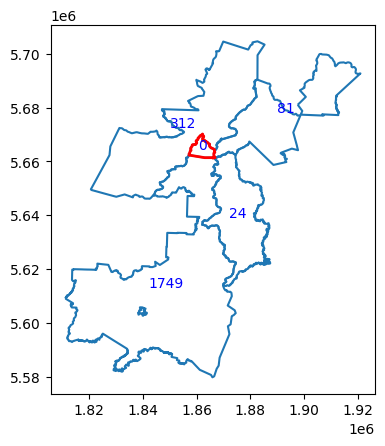

In [5]:
ax = neighbours.boundary.plot()
ax = dz.boundary.plot(ax=ax, color="red", linewidth=2)
p = dz.centroid.iloc[0]
ax.annotate(text=str(dz.VAR_1_3.iloc[0]), xy=[p.x, p.y], ha='center', color="blue")
for neighbour in neighbours.itertuples():
  p = neighbour.geometry.centroid
  ax.annotate(text=str(neighbour.VAR_1_3), xy=[p.x, p.y], ha='center', color="blue")

In [6]:
merged = pd.concat((dz, neighbours.iloc[0:1])).dissolve(aggfunc={
    "SA22023_V1_00": "first",
    "SA22023_V1_00_NAME": "first",
    "VAR_1_1": "sum",
    "VAR_1_2": "sum",
    "VAR_1_3": "sum",
    "n_SA2s": "sum"
})
merged.index = dz.index
merged

,geometry,SA22023_V1_00,SA22023_V1_00_NAME,VAR_1_1,VAR_1_2,VAR_1_3,n_SA2s
120,"MULTIPOLYGON (((1872254.198 5663396.582, 18723...",190000,Te More,27,24,24,2


<Axes: >

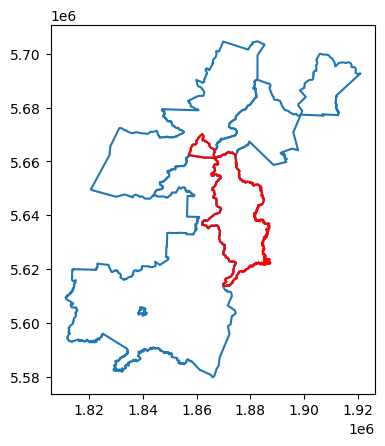

In [7]:
ax = neighbours.boundary.plot()
merged.boundary.plot(ax=ax, color="red")

In [8]:
concat = lambda l: "+".join([str(e) for e in l])
concat(range(10))

'0+1+2+3+4+5+6+7+8+9'

In [9]:
while sa2.VAR_1_3.iloc[0] < 399:
    dz = sa2.iloc[0:1]
    neighbours = sa2[sa2.geometry.touches(dz.geometry.iloc[0])]
    if neighbours.empty:
        print(f"No neighbours found for {dz.SA22023_V1_00.iloc[0]} ({dz.VAR_1_3.iloc[0]})")
        sa2.drop(dz.index[0], inplace=True)
        continue
    merged = pd.concat((dz, neighbours.iloc[0:1])).dissolve(aggfunc={
        "SA22023_V1_00": concat,
        "SA22023_V1_00_NAME": concat,
        "SA22023_V1_00_NAME_ASCII": concat,
        "VAR_1_3": "sum",
        "VAR_1_2": "sum",
        "VAR_1_1": "sum",
        "n_SA2s": "sum"
    })
    print(f"Merging {dz.SA22023_V1_00.iloc[0]} ({dz.VAR_1_3.iloc[0]}) with {neighbours.SA22023_V1_00.iloc[0]} ({neighbours.VAR_1_3.iloc[0]}) into {merged.SA22023_V1_00.iloc[0]} ({merged.VAR_1_3.iloc[0]})")
    merged.index = dz.index
    sa2.drop(neighbours.index[0], inplace=True)
    sa2.update(merged)
    sa2.sort_values("VAR_1_3", inplace=True)
sa2

Merging 190000 (0) with 226200 (24) into 190000+226200 (24)
No neighbours found for 259800 (0)
Merging 246500 (0) with 245700 (102) into 246500+245700 (102)
No neighbours found for 258100 (0)
No neighbours found for 364000 (0)
Merging 113700 (3) with 116300 (966) into 113700+116300 (969)
Merging 347600 (3) with 348000 (747) into 347600+348000 (750)
No neighbours found for 238700 (3)
No neighbours found for 236200 (3)
Merging 238200 (3) with 236100 (489) into 238200+236100 (492)


/tmp/ipykernel_9700/2349389213.py:20: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 27   0   0 ... 153 642 297]' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  sa2.update(merged)
/tmp/ipykernel_9700/2349389213.py:20: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[  24    0    0 ... 2745 2106  288]' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  sa2.update(merged)
/tmp/ipykernel_9700/2349389213.py:20: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[  24    0    0 ... 5553 5562 5697]' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  sa2.update(merged)


Merging 119301 (3) with 128700 (9) into 119301+128700 (12)
Merging 154600 (6) with 155301 (1872) into 154600+155301 (1878)
Merging 233900 (6) with 233801 (720) into 233900+233801 (726)
Merging 216200 (6) with 216600 (1908) into 216200+216600 (1914)
Merging 147700 (9) with 147400 (117) into 147700+147400 (126)
No neighbours found for 166600 (9)
Merging 119301+128700 (12) with 125100 (210) into 119301+128700+125100 (222)
Merging 118800 (15) with 117002 (1248) into 118800+117002 (1263)
Merging 326400 (24) with 324900 (150) into 326400+324900 (174)
Merging 190000+226200 (24) with 189900 (81) into 190000+226200+189900 (105)
Merging 161700 (27) with 161900 (2301) into 161700+161900 (2328)
Merging 314400 (33) with 314200 (1743) into 314400+314200 (1776)
No neighbours found for 258900 (33)
Merging 138800 (36) with 139100 (1983) into 138800+139100 (2019)
Merging 187600 (45) with 222300 (1077) into 187600+222300 (1122)
Merging 334801 (45) with 335202 (2337) into 334801+335202 (2382)
Merging 2550

,SA22023_V1_00,SA22023_V1_00_NAME,SA22023_V1_00_NAME_ASCII,VAR_1_1,VAR_1_2,VAR_1_3,VAR_1_4,VAR_1_5,AREA_SQ_KM,LAND_AREA_SQ_KM,Shape_Length,geometry,n_SA2s
2327,211600,Havelock North-Central,Havelock North-Central,420,441,423,5.0,-4.1,0.475459,0.475459,4034.302118,"MULTIPOLYGON (((1932989.236 5602283.541, 19330...",1
1260,223901,Springvale North,Springvale North,348,402,426,15.5,6.0,1.279383,1.279383,6234.143135,"MULTIPOLYGON (((1772489.345 5579929.321, 17725...",1
356,347300,Kingston,Kingston,237,348,429,46.8,23.3,1012.535943,1012.535943,231740.977586,"MULTIPOLYGON (((1231402.748 5006747.121, 12314...",1
1572,210500,Hastings Central,Hastings Central,366,444,429,21.3,-3.4,1.417448,1.417448,7377.983855,"MULTIPOLYGON (((1930770.141 5605963.092, 19306...",1
157,184700,Tokanui,Tokanui,441,435,441,-1.4,1.4,23.684809,23.684809,28826.135356,"MULTIPOLYGON (((1802470.815 5787542.996, 18024...",1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
953,109301,Dargaville,Dargaville,4284,4827,5016,12.7,3.9,12.857900,12.857900,22435.405699,"MULTIPOLYGON (((1678269.425 6024387.291, 16782...",1
160,117001,Whenuapai,Whenuapai,3150,3270,5052,3.8,54.5,12.753226,12.753226,26571.209745,"MULTIPOLYGON (((1743880.554 5928979.708, 17438...",1
252,335501,Faringdon,Faringdon,153,2745,5553,1694.1,102.3,3.566076,3.566076,9064.072284,"MULTIPOLYGON (((1549864.157 5168679.437, 15498...",1
1860,120202,Hobsonville Point Park,Hobsonville Point Park,642,2106,5562,228.0,164.1,1.033846,1.033846,6576.909403,"MULTIPOLYGON (((1748048.931 5927315.847, 17480...",1


In [10]:
sa2[sa2.n_SA2s > 1].sort_values("n_SA2s", ascending=False)

,SA22023_V1_00,SA22023_V1_00_NAME,SA22023_V1_00_NAME_ASCII,VAR_1_1,VAR_1_2,VAR_1_3,VAR_1_4,VAR_1_5,AREA_SQ_KM,LAND_AREA_SQ_KM,Shape_Length,geometry,n_SA2s
2167,326600+326400+324900+323500+324200+325500,Christchurch Central+Addington North+Hagley Pa...,Christchurch Central+Addington North+Hagley Pa...,495,510,708,266.7,15.2,0.713926,0.713926,4683.493839,"POLYGON ((1565777.233 5179236.243, 1565805.641...",6
120,190000+226200+189900+189800+189500,Te More+Ngamatea+Taharua+Rangataiki+Kaimanawa,Te More+Ngamatea+Taharua+Rangataiki+Kaimanawa,225,393,540,-998.0,-998.0,47.922581,47.922581,33420.011116,"POLYGON ((1874551.266 5662289.604, 1874550.63 ...",5
1216,147700+147400+149600+144201+145900,Mount Wellington Industrial+Sylvia Park+Ōtāhuh...,Mount Wellington Industrial+Sylvia Park+Otahuh...,918,1185,1422,100.0,-50.0,3.332355,3.332355,14297.249182,"POLYGON ((1763216.507 5910035.47, 1763225.101 ...",5
575,312100+333600+336600+338600,Hanmer Range+Craigieburn+Ashburton Lakes+Ben M...,Hanmer Range+Craigieburn+Ashburton Lakes+Ben M...,735,642,753,2.4,20.0,3622.672551,3609.134819,431868.008802,"POLYGON ((1457858.416 5152781.951, 1457910.744...",4
818,119301+128700+125100+133900,Inlet Waitemata Harbour+Rosebank Peninsula+Hen...,Inlet Waitemata Harbour+Rosebank Peninsula+Hen...,495,795,720,300.0,-96.4,79.264725,0.057126,306779.325980,"MULTIPOLYGON (((1750626.591 5913558.089, 17506...",4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1200,117003+120101,Massey Red Hills+Birdwood West,Massey Red Hills+Birdwood West,828,867,1131,16.7,112.2,3.435590,3.435590,9383.302285,"POLYGON ((1742373.984 5921917.303, 1742379.241...",2
678,238200+236100,Tararua Forest Park+Kimberley,Tararua Forest Park+Kimberley,399,447,492,-998.0,-998.0,365.625246,365.625246,158665.699145,"POLYGON ((1801394.504 5488295.355, 1801433.77 ...",2
1009,217701+218801,Waiwhakaiho-Bell Block South+Paraite,Waiwhakaiho-Bell Block South+Paraite,954,1050,1173,-5.6,15.7,7.468558,7.468558,20718.854378,"POLYGON ((1703579.26 5677844.759, 1703581.351 ...",2
137,190100+190400,Waiau+Athenree,Waiau+Athenree,1002,1137,1236,1.8,-0.9,36.092105,36.092105,46678.970351,"POLYGON ((1861720.631 5852770.799, 1861735.588...",2


In [11]:
print(sa2.sort_values("n_SA2s").iloc[-1].drop("geometry").to_markdown())

|                          | 2167                                                                                        |
|:-------------------------|:--------------------------------------------------------------------------------------------|
| SA22023_V1_00            | 326600+326400+324900+323500+324200+325500                                                   |
| SA22023_V1_00_NAME       | Christchurch Central+Addington North+Hagley Park+Middleton+Riccarton Central+Tower Junction |
| SA22023_V1_00_NAME_ASCII | Christchurch Central+Addington North+Hagley Park+Middleton+Riccarton Central+Tower Junction |
| VAR_1_1                  | 495                                                                                         |
| VAR_1_2                  | 510                                                                                         |
| VAR_1_3                  | 708                                                                                         |
| VAR_1_4       

In [15]:
sa2.to_file("output/SA2_2023_merged_small_dz.shz")

/tmp/ipykernel_9700/4284823032.py:1: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  sa2.to_file("output/SA2_2023_merged_small_dz.shz")
/home/nyou045/.local/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'SA22023_V1_00' to 'SA22023_V1'
  ogr_write(
/home/nyou045/.local/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'SA22023_V1_00_NAME' to 'SA22023__1'
  ogr_write(
/home/nyou045/.local/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'SA22023_V1_00_NAME_ASCII' to 'SA22023__2'
  ogr_write(
/home/nyou045/.local/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'LAND_AREA_SQ_KM' to 'LAND_AREA_'
  ogr_write(
/home/nyou045/.local/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'Shape_Length' to

In [21]:
sa2.VAR_1_3.describe()

count    2190.000000
mean     2279.920548
std       941.772490
min       423.000000
25%      1524.750000
50%      2247.000000
75%      2972.250000
max      5697.000000
Name: VAR_1_3, dtype: float64

<Axes: title={'center': 'Population in SA2s after merging small SA2s'}, xlabel='Population', ylabel='Count'>

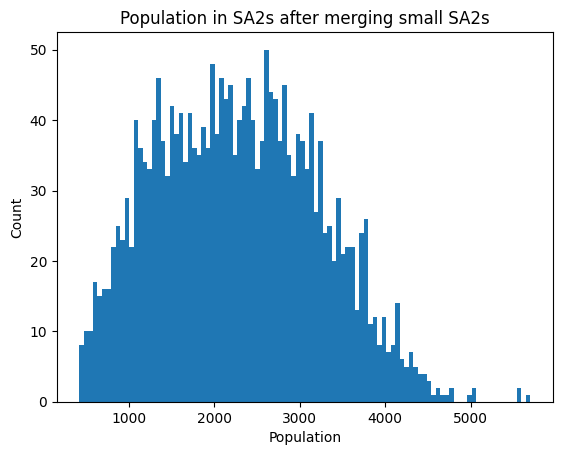

In [20]:
sa2.VAR_1_3.plot.hist(bins=100, xlabel="Population", ylabel="Count", title="Population in SA2s after merging small SA2s")